In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from importlib import reload

import lspr

In [20]:
########################################
# -- Step 1 --
# Write the "xy_to_radec" function in "lspr.py", then run this cell to test it
########################################

reload(lspr)
lspr.main()


TEST 1: x, y = 0 0

Actual:   271.23586782
Expected: 271.23586782
Difference: 0.0

Actual:   14.692310024
Expected: 14.692310024
Difference: 0.0

TEST 2: x, y = 100 0

Actual:   271.03391682
Expected: 271.03391682
Difference: 0.0

Actual:   14.970271724
Expected: 14.970271724
Difference: 0.0

TEST 3: x, y = 57.3 201.1

Actual:   270.6119854806
Expected: 270.6119854806
Difference: 0.0

Actual:   14.482378968299999
Expected: 14.4823789683
Difference: -1.7763568394002505e-15



Text(0.5, 1.0, 'Coordinates of Reference Stars')

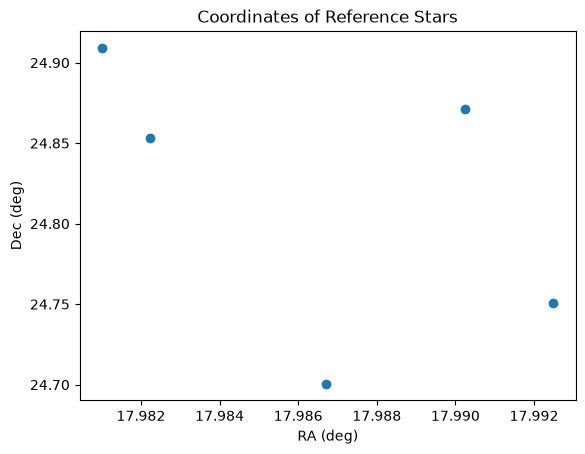

In [21]:
########################################
# -- Step 2 --
# Load the reference star catalog and plot their Dec vs. RA locations
########################################

star_positions = pd.read_csv("reference_stars.csv")

plt.scatter(star_positions["ra_deg"], star_positions["dec_deg"])

plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")
plt.title("Coordinates of Reference Stars")

In [22]:
########################################
# -- Step 3 --
# Compute the plate solution coefficients
# (You may want to use multiple cells to spread out your work)
########################################


# column vectors
x = star_positions["x_pix"]
y = star_positions["y_pix"]
ra = star_positions["ra_deg"]
dec = star_positions["dec_deg"]

# compute the xy matrix
N = len(star_positions)
xy_matrix = np.array([
    [N, np.sum(x), np.sum(y)],
    [np.sum(x), np.sum(x**2), np.sum(x*y)],
    [np.sum(y), np.sum(x*y), np.sum(y**2)]
])

# compute LHS vector for RA and Dec
lhs_ra = np.array([np.sum(ra), np.sum(x * ra), np.sum(y * ra)])
lhs_dec = np.array([np.sum(dec), np.sum(x * dec), np.sum(y * dec)])

# compute the plate solution coefficients 
b1, a11, a12 = np.linalg.solve(xy_matrix, lhs_ra)
b2, a21, a22 = np.linalg.solve(xy_matrix, lhs_dec)

print(b1, a11, a12, b2, a21, a22)

18.004703620185744 -1.5156908053021846e-05 3.956291357179146e-08 24.548673558023122 5.457678714005983e-07 0.0002063108503416389


### Response 1 - Answer in your Jupyter notebook

1. When x and y are both 0, RA and Dec are 313.66771433930927 and -4.458977263858225 respectively because the other coefficients get 0-ed out.
2. As x increases, both RA and Dec **decrease** because the coefficient in front of x is negative, and the values become more negative. The RA will change more and faster because the coefficient for it is bigger.
3. As y increases, RA **increases** and Dec **decreases** due to the signs of their coefficients. 
4. The larger the Dec is, the closer it is to the North Pole. All the coefficients are negative for Declination, so we know that the variable has to be negative to maximize the product. The coefficient for y happens to be larger in magnitude than x, so ultimately **negative y** would result in a closer Declination to the North Pole.

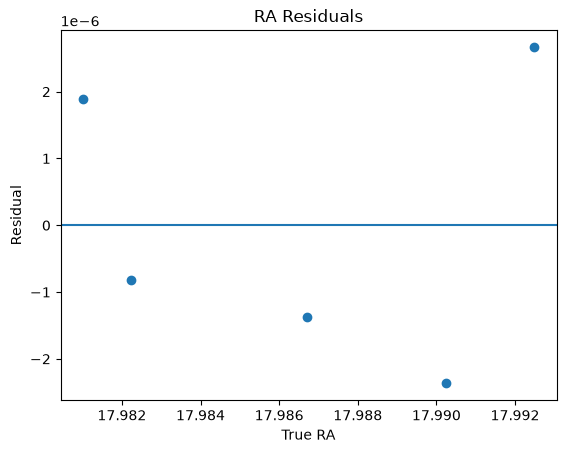

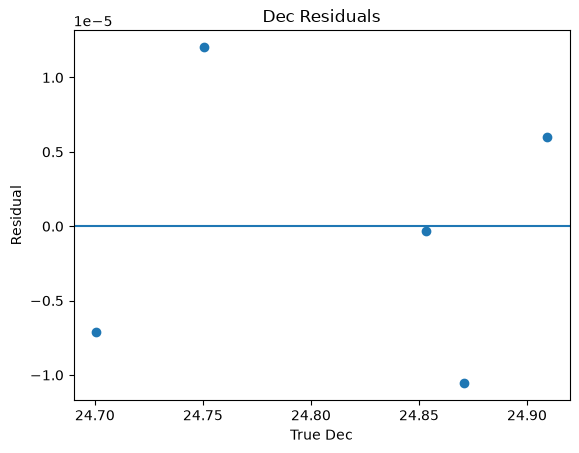

In [23]:
########################################
# -- Step 4 --
# Compute the RA & Dec value of each star using your plate solve, then plot the residuals
########################################

# compute estimated coordinates
ra_estimates, dec_estimates = lspr.xy_to_radec(star_positions["x_pix"], star_positions["y_pix"], b1, a11, a12, b2, a21, a22)

# compute residuals by finding the difference
ra_residuals = ra_estimates - star_positions["ra_deg"]
dec_residuals = dec_estimates - star_positions["dec_deg"]

# plotting the RA residuals
plt.scatter(star_positions["ra_deg"], ra_residuals)
plt.axhline(0)
plt.xlabel("True RA")
plt.ylabel("Residual")
plt.title("RA Residuals")
plt.show()

# plotting the dec residuals
plt.scatter(star_positions["dec_deg"], dec_residuals)
plt.axhline(0)
plt.xlabel("True Dec")
plt.ylabel("Residual")
plt.title("Dec Residuals")
plt.show()

### Response 2 - Answer in your Jupyter notebook

1. If every RA residual was positive, it would indicate that the plate solution is consistently overshooting and is not a good fit because it has a higher bias.
2. If the RA residuals always increased as RA increased, it would indicate that as the RA values be

In [24]:
########################################
# -- Step 5 --
# Determine your asteroid's coordinates (x=50, y=25)
########################################

asteroid_ra, asteroid_dec = lspr.xy_to_radec(50, 25, b1, a11, a12, b2, a21, a22)

print("RA =", asteroid_ra)
print("Dec =", asteroid_dec)


RA = 18.003946763855932
Dec = 24.553858617675235
